In [1]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nCSV files found:")

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

Current working directory:
c:\Users\Divya Nayana\Downloads\Trader-Sentiment-Analysis\notebook

CSV files found:
.\fear_greed_index.csv
.\historical_data (1).csv


In [2]:
# ============================
# Trader Performance vs Market Sentiment
# Data Science Internship Assignment
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data (1).csv")

print("Fear & Greed Dataset Shape:", fear.shape)
print("Trader Dataset Shape:", trades.shape)

print("\nFear Dataset Columns")
print(fear.columns)

print("\nTrader Dataset Columns")
print(trades.columns)

Fear & Greed Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)

Fear Dataset Columns
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

Trader Dataset Columns
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [3]:
# Missing Values

print("Fear Missing Values")
print(fear.isnull().sum())

print("\nTrader Missing Values")
print(trades.isnull().sum())

# Duplicate Records

print("\nFear Duplicates:", fear.duplicated().sum())
print("Trader Duplicates:", trades.duplicated().sum())

Fear Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear Duplicates: 0
Trader Duplicates: 0


In [4]:
# Convert dates correctly

fear["date"] = pd.to_datetime(fear["date"]).dt.date

trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

trades["date"] = trades["Timestamp IST"].dt.date

# Merge
df = pd.merge(
    trades,
    fear[["date", "classification"]],
    on="date",
    how="left"
)

print(df.head())
print(df.shape)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [5]:
# -----------------------------
# Feature Engineering
# -----------------------------

# Win / Loss
df["Win"] = (df["Closed PnL"] > 0).astype(int)

# Daily PnL
daily_pnl = df.groupby(["date", "classification"])["Closed PnL"].sum().reset_index()

# Win Rate
win_rate = df.groupby("classification")["Win"].mean() * 100

# Average Trade Size
avg_trade = df.groupby("classification")["Size USD"].mean()

# Average Position Size
avg_position = df.groupby("classification")["Start Position"].mean()

# Number of Trades
trade_count = df.groupby("classification").size()

# Buy / Sell Ratio
buy_sell = df.groupby(["classification", "Side"]).size().unstack(fill_value=0)

print("========== Win Rate ==========")
print(win_rate)

print("\n========== Average Trade Size ==========")
print(avg_trade)

print("\n========== Trade Count ==========")
print(trade_count)

========== Win Rate ==========
classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

========== Average Trade Size ==========
classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

========== Trade Count ==========
classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


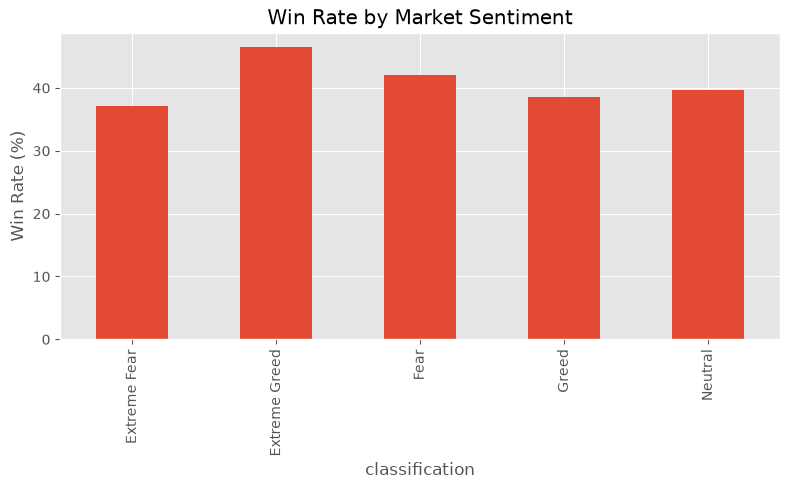

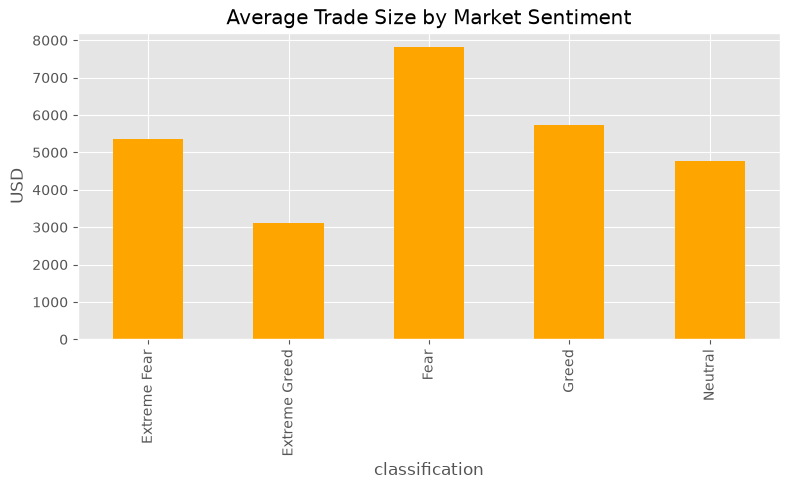

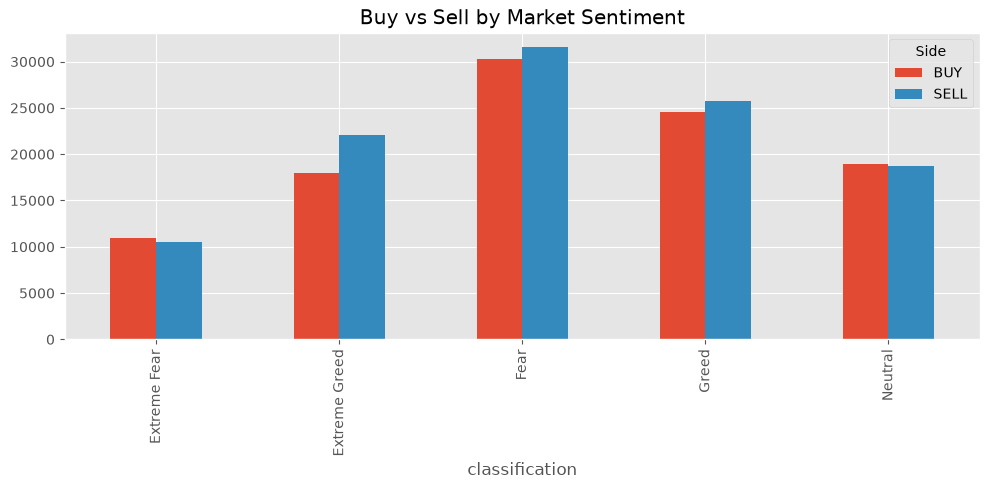

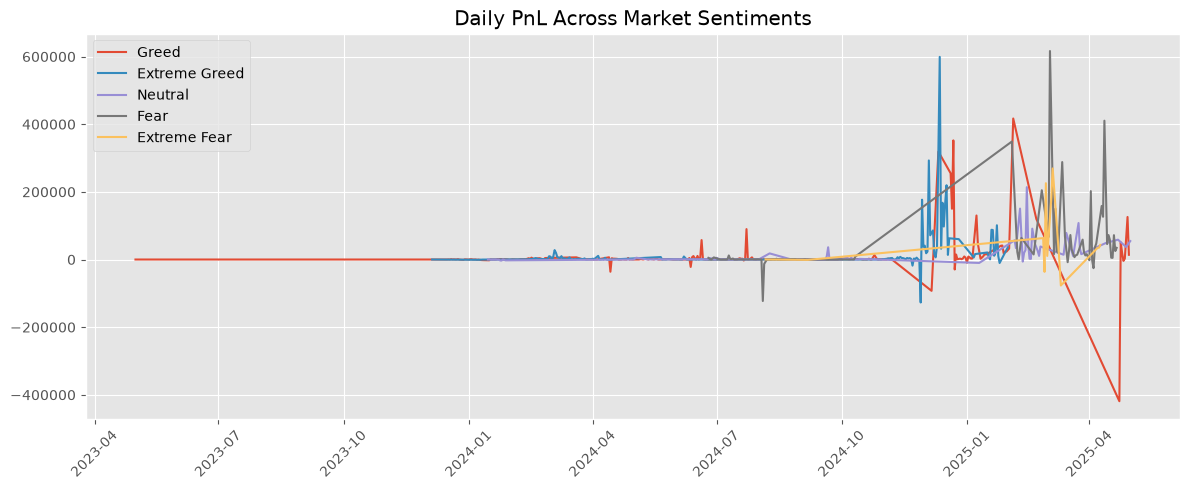

In [6]:
import matplotlib.pyplot as plt

# Win Rate
plt.figure(figsize=(8,5))
win_rate.plot(kind="bar")
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.tight_layout()
plt.show()

# Average Trade Size
plt.figure(figsize=(8,5))
avg_trade.plot(kind="bar", color="orange")
plt.title("Average Trade Size by Market Sentiment")
plt.ylabel("USD")
plt.tight_layout()
plt.show()

# Buy vs Sell
buy_sell.plot(kind="bar", figsize=(10,5))
plt.title("Buy vs Sell by Market Sentiment")
plt.tight_layout()
plt.show()

# Daily PnL
plt.figure(figsize=(12,5))
for cls in daily_pnl["classification"].unique():
    temp = daily_pnl[daily_pnl["classification"] == cls]
    plt.plot(temp["date"], temp["Closed PnL"], label=cls)

plt.legend()
plt.title("Daily PnL Across Market Sentiments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()